In [1]:
student_data <- read.csv("/content/student_math.csv")

In [2]:
head(student_data)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,⋯,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>
1,GP,F,18,U,GT3,A,4,4,at_home,teacher,⋯,4,?,4,1,1,3,NaN,5,6,6
2,GP,F,17,U,GT3,T,1,1,at_home,other,⋯,5,?,3,1,1,3,NaN,5,5,6
3,GP,Female,15,U,LE3,T,1,1,at_home,other,⋯,4,3,2,2,3,3,10,7,8,10
4,GP,F,15,U,GT3,T,4,2,health,services,⋯,3,2,2,1,1,5,2,15,14,15
5,GP,F,16,U,GT3,T,3,3,other,other,⋯,4,3,2,1,2,5,4,6,10,10
6,GP,Male,16,U,LE3,T,4,3,services,other,⋯,5,4,2,1,2,5,10,15,15,15


In [3]:
dim(student_data)

[1] 395  33

In [4]:
summary(student_data)

       school           sex           age            address         famsize   
 Length   :395   Length   :395   Min.   :15.0   Length   :395   Length   :395  
 N.unique :  3   N.unique :  5   1st Qu.:16.0   N.unique :  3   N.unique :  2  
 N.blank  : 22   N.blank  :  1   Median :17.0   N.blank  :  1   N.blank  :  0  
 Min.nchar:  0   Min.nchar:  0   Mean   :16.7   Min.nchar:  0   Min.nchar:  3  
 Max.nchar:  2   Max.nchar:  6   3rd Qu.:18.0   Max.nchar:  1   Max.nchar:  3  
                                 Max.   :22.0                                  
                                 NAs    :1                                     
      Pstatus         Medu            Fedu              Mjob    
 Length   :395   Min.   :0.000   Min.   :0.000   Length   :395  
 N.unique :  2   1st Qu.:2.000   1st Qu.:2.000   N.unique :  5  
 N.blank  :  0   Median :3.000   Median :2.000   N.blank  :  0  
 Min.nchar:  1   Mean   :2.749   Mean   :2.522   Min.nchar:  5  
 Max.nchar:  1   3rd Qu.:4.000   3r

In [5]:
sum(is.na(student_data))


[1] 7

In [6]:
colSums(is.na(student_data))

school        sex        age    address    famsize    Pstatus       Medu 
         0          0          1          0          0          0          0 
      Fedu       Mjob       Fjob     reason   guardian traveltime  studytime 
         0          0          0          0          0          0          0 
  failures  schoolsup     famsup       paid activities    nursery     higher 
         2          0          0          0          0          0          0 
  internet   romantic     famrel   freetime      goout       Dalc       Walc 
         0          0          0          0          0          0          0 
    health   absences         G1         G2         G3 
         0          2          2          0          0

In [7]:
sum(duplicated(student_data))

[1] 0

In [8]:
# Remove the row with the missing age value because there is only one missing record
student_data <- student_data[!is.na(student_data$age), ]

In [9]:
sum(is.na(student_data$age))

[1] 0

In [10]:
# Missing values were replaced with 0 since the mode of the failures column is 0
student_data$failures[is.na(student_data$failures)] <- 0

In [11]:
sum(is.na(student_data$failures))

[1] 0

In [12]:
# Missing values were replaced with the median because it is more robust to outliers.
student_data$absences[is.na(student_data$absences)] <- median(student_data$absences, na.rm = TRUE)

In [13]:
sum(is.na(student_data$absences))

[1] 0

In [14]:
colSums(student_data == "", na.rm = TRUE)

school        sex        age    address    famsize    Pstatus       Medu 
        21          0          0          0          0          0          0 
      Fedu       Mjob       Fjob     reason   guardian traveltime  studytime 
         0          0          0          0          0          0          0 
  failures  schoolsup     famsup       paid activities    nursery     higher 
         0          0          0          0          0          0          0 
  internet   romantic     famrel   freetime      goout       Dalc       Walc 
         0          0          0          0          0          0          0 
    health   absences         G1         G2         G3 
         0          0          0          0          0

In [15]:
str(student_data)

'data.frame':	394 obs. of  33 variables:
 $ school    : chr  "GP" "GP" "GP" "GP" ...
 $ sex       : chr  "F" "F" "Female" "F" ...
 $ age       : int  18 17 15 15 16 16 16 15 15 15 ...
 $ address   : chr  "U" "U" "U" "U" ...
 $ famsize   : chr  "GT3" "GT3" "LE3" "GT3" ...
 $ Pstatus   : chr  "A" "T" "T" "T" ...
 $ Medu      : int  4 1 1 4 3 4 2 3 3 4 ...
 $ Fedu      : int  4 1 1 2 3 3 2 2 4 4 ...
 $ Mjob      : chr  "at_home" "at_home" "at_home" "health" ...
 $ Fjob      : chr  "teacher" "other" "other" "services" ...
 $ reason    : chr  "course" "course" "other" "home" ...
 $ guardian  : chr  "mother" "father" "mother" "mother" ...
 $ traveltime: int  2 1 1 1 1 1 1 1 1 1 ...
 $ studytime : int  2 2 2 3 2 2 2 2 2 2 ...
 $ failures  : num  0 0 3 0 0 0 0 0 0 0 ...
 $ schoolsup : chr  "yes" "no" "yes" "no" ...
 $ famsup    : chr  "no" "yes" "no" "yes" ...
 $ paid      : chr  "no" "no" "yes" "yes" ...
 $ activities: chr  "no" "no" "no" "yes" ...
 $ nursery   : chr  "yes" "no" "yes" "yes" .

In [16]:
# Standardize the sex column by converting "Female" to "F" for consistency
student_data$sex[student_data$sex == "Female"] <- "F"

In [17]:
unique(student_data$sex)

[1] "F"    "Male" "M"

In [18]:
# Standardize the sex column by converting "Male" to "M" for consistency
student_data$sex[student_data$sex == "Male"] <- "M"

In [19]:
unique(student_data$sex)

[1] "F" "M"

In [20]:
# Replace "?" values with NA
student_data$freetime[student_data$freetime == "?"] <- NA

In [21]:
# Convert freetime from character to numeric because it contains
# numerical values (1-5) and needs to be treated as a numeric variable for analysis.
student_data$freetime <- as.numeric(student_data$freetime)

In [22]:
student_data$freetime[is.na(student_data$freetime)] <- median(student_data$freetime, na.rm = TRUE)

In [23]:
student_data$failures <- as.integer(student_data$failures)

In [24]:
student_data$absences <- as.integer(student_data$absences)

In [25]:
str(student_data)

'data.frame':	394 obs. of  33 variables:
 $ school    : chr  "GP" "GP" "GP" "GP" ...
 $ sex       : chr  "F" "F" "F" "F" ...
 $ age       : int  18 17 15 15 16 16 16 15 15 15 ...
 $ address   : chr  "U" "U" "U" "U" ...
 $ famsize   : chr  "GT3" "GT3" "LE3" "GT3" ...
 $ Pstatus   : chr  "A" "T" "T" "T" ...
 $ Medu      : int  4 1 1 4 3 4 2 3 3 4 ...
 $ Fedu      : int  4 1 1 2 3 3 2 2 4 4 ...
 $ Mjob      : chr  "at_home" "at_home" "at_home" "health" ...
 $ Fjob      : chr  "teacher" "other" "other" "services" ...
 $ reason    : chr  "course" "course" "other" "home" ...
 $ guardian  : chr  "mother" "father" "mother" "mother" ...
 $ traveltime: int  2 1 1 1 1 1 1 1 1 1 ...
 $ studytime : int  2 2 2 3 2 2 2 2 2 2 ...
 $ failures  : int  0 0 3 0 0 0 0 0 0 0 ...
 $ schoolsup : chr  "yes" "no" "yes" "no" ...
 $ famsup    : chr  "no" "yes" "no" "yes" ...
 $ paid      : chr  "no" "no" "yes" "yes" ...
 $ activities: chr  "no" "no" "no" "yes" ...
 $ nursery   : chr  "yes" "no" "yes" "yes" ...
 $

In [26]:
unique(student_data$freetime)
unique(student_data$sex)
unique(student_data$school)

[1] 3 2 4 5 1

[1] "F" "M"

[1] "GP" ""   "MS"

In [27]:
sapply(student_data, class)

school         sex         age     address     famsize     Pstatus 
"character" "character"   "integer" "character" "character" "character" 
       Medu        Fedu        Mjob        Fjob      reason    guardian 
  "integer"   "integer" "character" "character" "character" "character" 
 traveltime   studytime    failures   schoolsup      famsup        paid 
  "integer"   "integer"   "integer" "character" "character" "character" 
 activities     nursery      higher    internet    romantic      famrel 
"character" "character" "character" "character" "character"   "integer" 
   freetime       goout        Dalc        Walc      health    absences 
  "numeric"   "integer"   "integer"   "integer"   "integer"   "integer" 
         G1          G2          G3 
  "integer"   "integer"   "integer"

In [28]:
# Convert school to a factor because it is a categorical variable.
student_data$school <- as.factor(student_data$school)

# Convert sex to a factor because it is a categorical variable.
student_data$sex <- as.factor(student_data$sex)

In [29]:
sapply(student_data, class)

school         sex         age     address     famsize     Pstatus 
   "factor"    "factor"   "integer" "character" "character" "character" 
       Medu        Fedu        Mjob        Fjob      reason    guardian 
  "integer"   "integer" "character" "character" "character" "character" 
 traveltime   studytime    failures   schoolsup      famsup        paid 
  "integer"   "integer"   "integer" "character" "character" "character" 
 activities     nursery      higher    internet    romantic      famrel 
"character" "character" "character" "character" "character"   "integer" 
   freetime       goout        Dalc        Walc      health    absences 
  "numeric"   "integer"   "integer"   "integer"   "integer"   "integer" 
         G1          G2          G3 
  "integer"   "integer"   "integer"

In [30]:
summary(student_data)

 school   sex          age            address         famsize   
   : 21   F:207   Min.   :15.0   Length   :394   Length   :394  
 GP:327   M:187   1st Qu.:16.0   N.unique :  2   N.unique :  2  
 MS: 46           Median :17.0   N.blank  :  0   N.blank  :  0  
                  Mean   :16.7   Min.nchar:  1   Min.nchar:  3  
                  3rd Qu.:18.0   Max.nchar:  1   Max.nchar:  3  
                  Max.   :22.0                                  
                                                                
      Pstatus         Medu            Fedu              Mjob    
 Length   :394   Min.   :0.000   Min.   :0.000   Length   :394  
 N.unique :  2   1st Qu.:2.000   1st Qu.:2.000   N.unique :  5  
 N.blank  :  0   Median :3.000   Median :2.000   N.blank  :  0  
 Min.nchar:  1   Mean   :2.746   Mean   :2.518   Min.nchar:  5  
 Max.nchar:  1   3rd Qu.:4.000   3rd Qu.:3.000   Max.nchar:  8  
                 Max.   :4.000   Max.   :4.000                  
                         

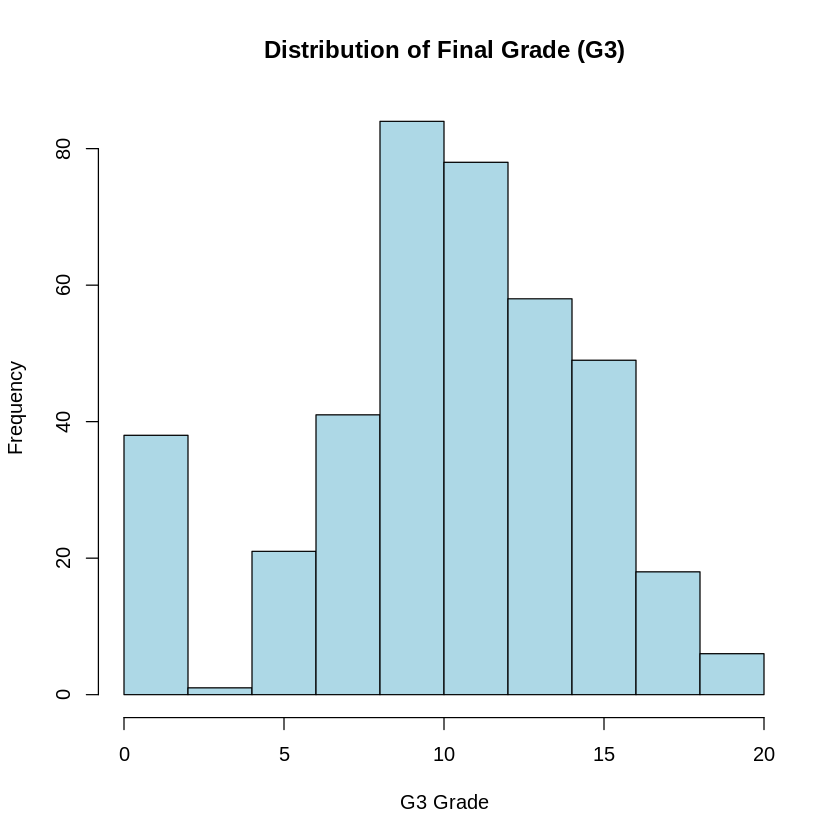

In [31]:
hist(student_data$G3,
     main = "Distribution of Final Grade (G3)",
     xlab = "G3 Grade",
     col = "lightblue")

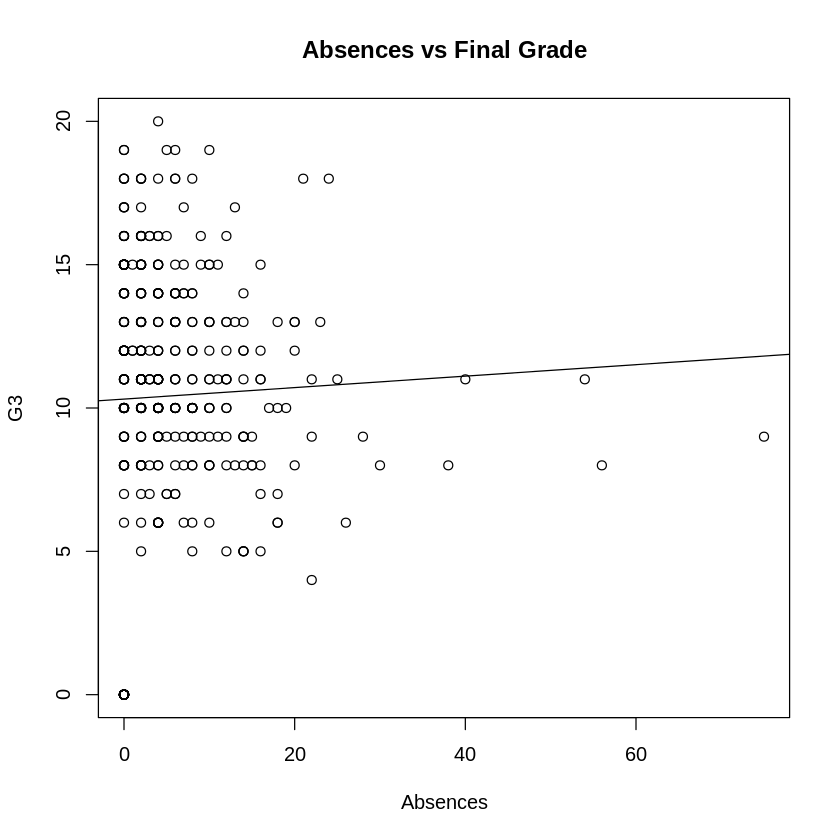

In [33]:
plot(student_data$absences, student_data$G3,
     main="Absences vs Final Grade",
     xlab="Absences",
     ylab="G3")

# Add linear regression line
abline(lm(G3 ~ absences, data = student_data))

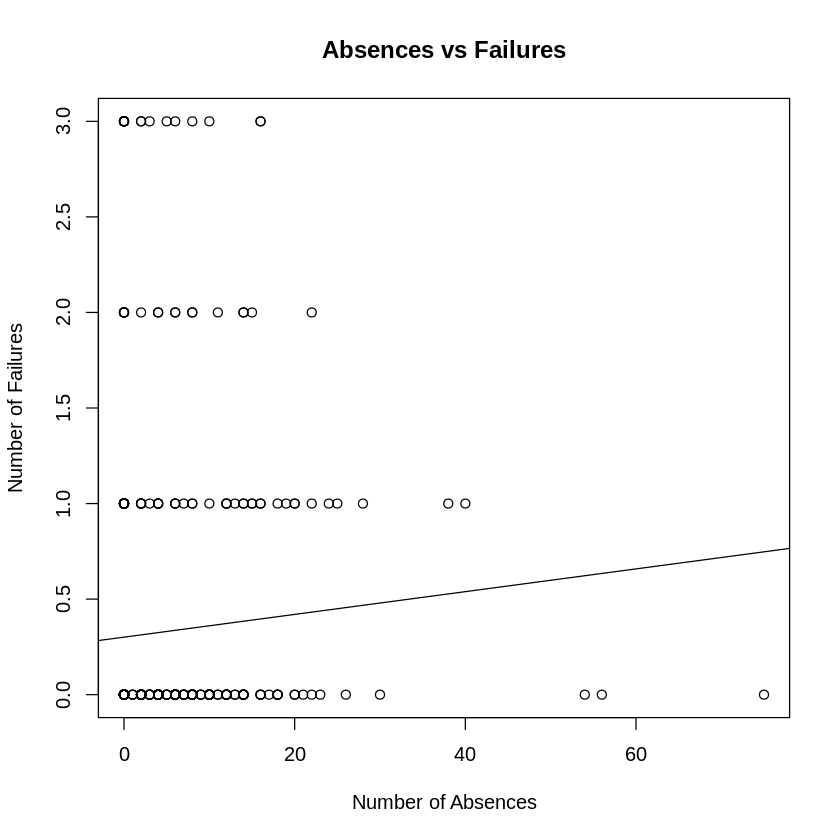

In [37]:
# Explore the relationship between absences and failures because both factors may be related and can have an important impact on students' academic performance.
plot(student_data$absences, student_data$failures,
     main = "Absences vs Failures",
     xlab = "Number of Absences",
     ylab = "Number of Failures")
     abline(lm(failures ~ absences, data = student_data))

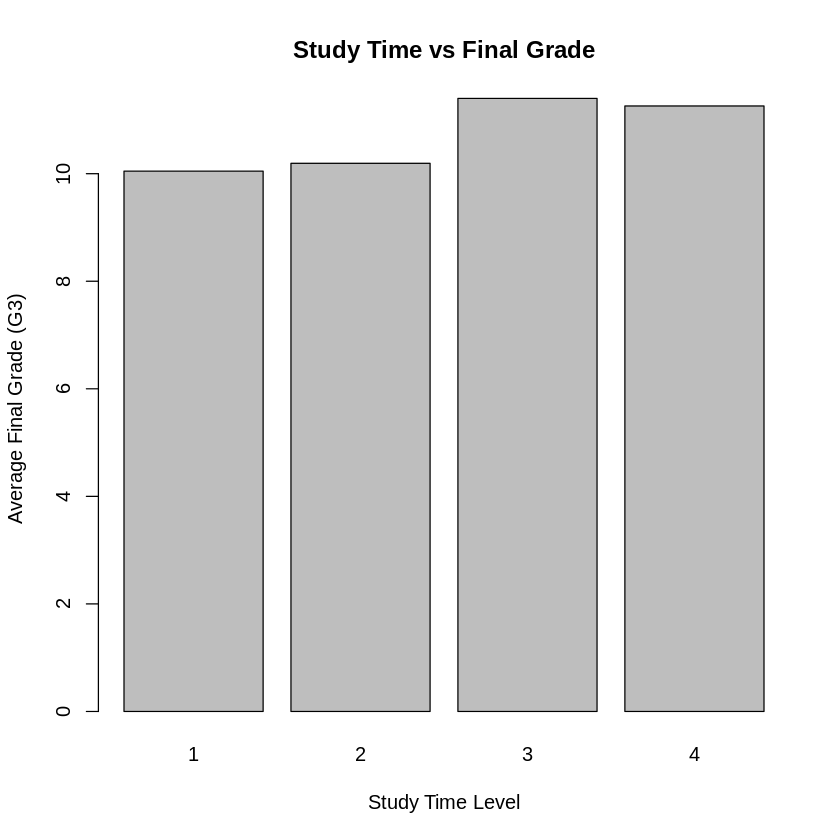

In [39]:
# Calculate the average final grade for each study time level
study_avg <- aggregate(G3 ~ studytime, data = student_data, mean)

# Create bar plot
barplot(study_avg$G3,
        names.arg = study_avg$studytime,
        main = "Study Time vs Final Grade",
        xlab = "Study Time Level",
        ylab = "Average Final Grade (G3)")

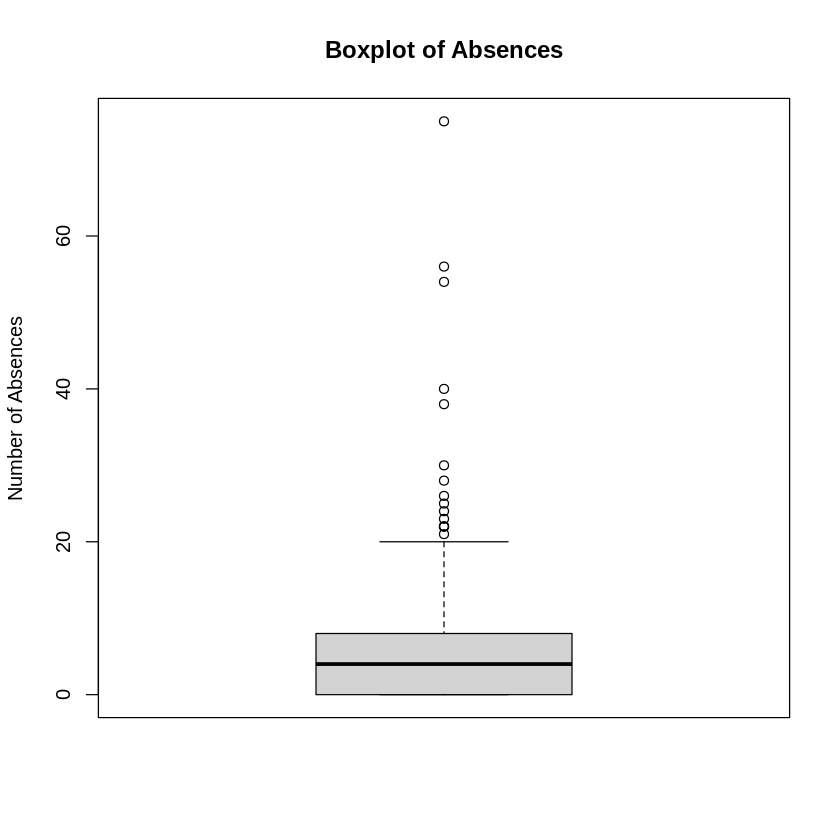

In [35]:
boxplot(student_data$absences,
        main = "Boxplot of Absences",
        ylab = "Number of Absences")

 Outliers were detected in the absences column. However, they were not removed because high absence values may represent real student behavior and could provide important information that affects the final grade (G3).

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


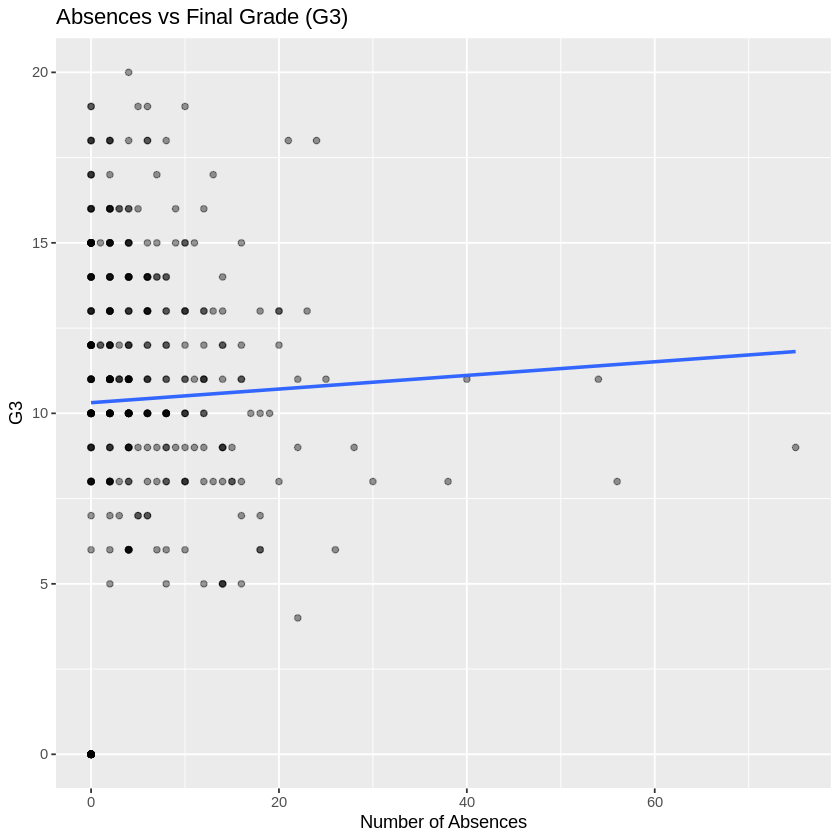

`geom_smooth()` using formula = 'y ~ x'


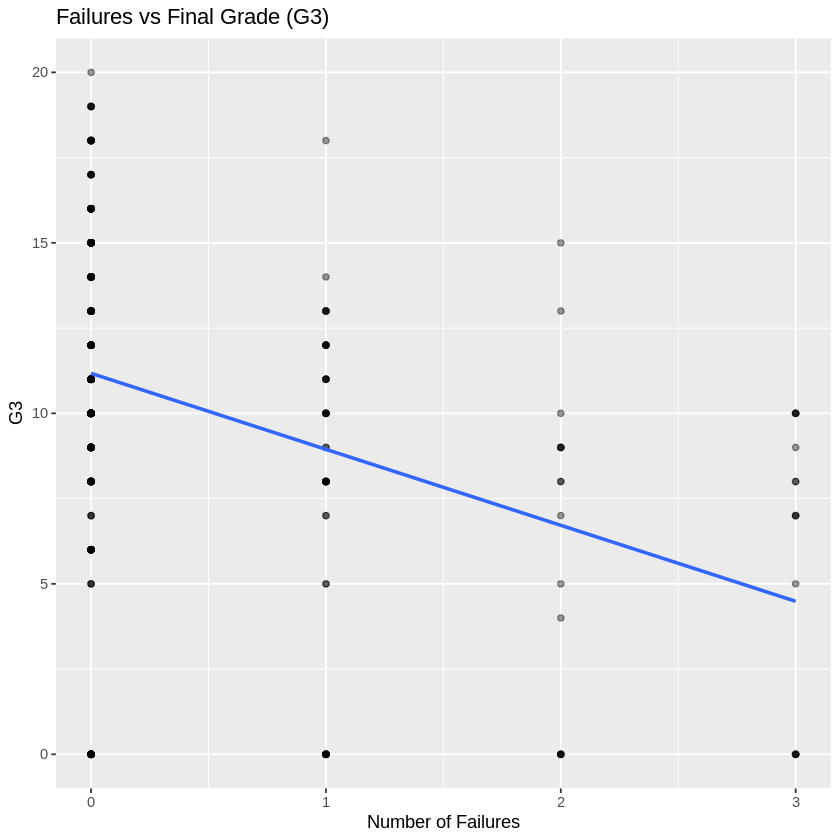

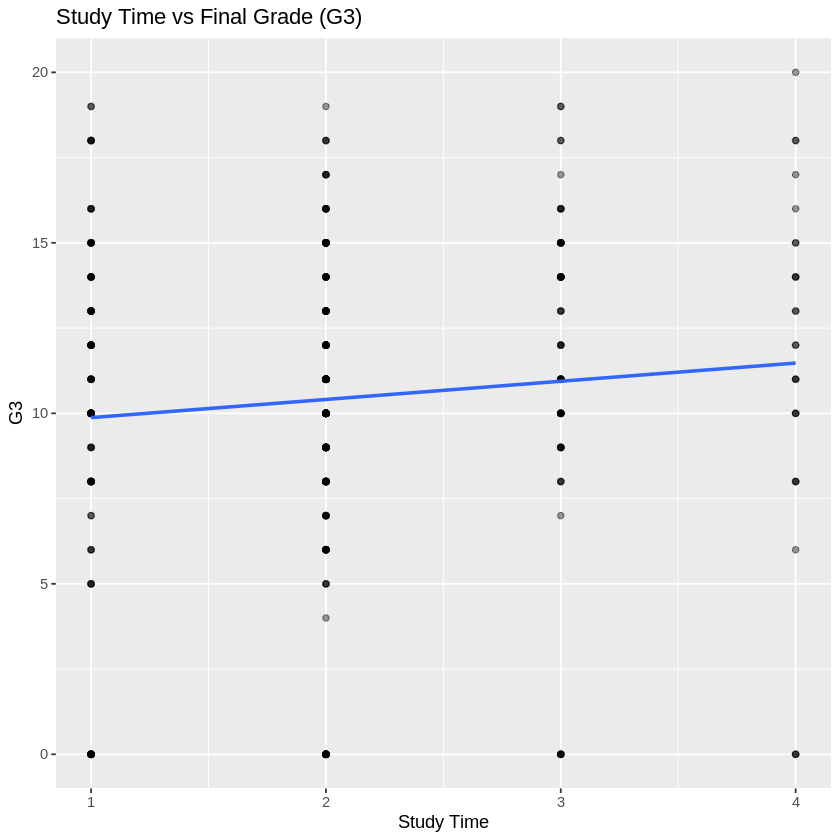

In [41]:
library(ggplot2)

# Absences vs G3
ggplot(student_data, aes(x = absences, y = G3)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Absences vs Final Grade (G3)",
       x = "Number of Absences",
       y = "G3")


# Failures vs G3
ggplot(student_data, aes(x = failures, y = G3)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Failures vs Final Grade (G3)",
       x = "Number of Failures",
       y = "G3")


# Study Time vs G3
ggplot(student_data, aes(x = studytime, y = G3)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Study Time vs Final Grade (G3)",
       x = "Study Time",
       y = "G3")

In [43]:

# Absences vs G3: A negative trend may be observed, indicating that higher absence rates may be associated with lower final grades.

# Failures vs G3: A clear negative trend may appear, suggesting that students with more previous failures tend to have lower final grades.

# Study Time vs G3: A positive trend may be observed, indicating that increased study time may be associated with higher final grades.

In [44]:
# Calculate correlations between numerical variables
cor(student_data[, c("age", "Medu", "Fedu", "traveltime",
                     "studytime", "failures", "famrel",
                     "freetime", "goout", "Dalc", "Walc",
                     "health", "absences", "G1", "G2", "G3")])

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000000,-0.164635924,-0.164660131,0.07022241,-0.004114759,0.24401790,0.053906619,0.017905895,0.126591325,0.131510022,0.118042906,-0.061342764,0.17456271,NA,-0.14298449,-0.161197824
Medu,-0.164635924,1.000000000,0.621999384,-0.17436783,0.065175356,-0.23582608,-0.004101856,0.037699659,0.061920908,0.021447435,-0.044339593,-0.041785975,0.09961278,NA,0.22095860,0.220575783
Fedu,-0.164660131,0.621999384,1.000000000,-0.16143739,-0.009049937,-0.24950553,-0.001588207,-0.005153567,0.040465454,0.004264916,-0.009198588,0.021234432,0.02353725,NA,0.17104880,0.156340585
traveltime,0.070222406,-0.174367833,-0.161437390,1.00000000,-0.100904725,0.09324173,-0.016946632,-0.012609706,0.026971539,0.139575511,0.136417268,0.011257134,-0.01353021,NA,-0.15070241,-0.115430118
studytime,-0.004114759,0.065175356,-0.009049937,-0.10090473,1.000000000,-0.17365634,0.039737664,-0.144362085,-0.063869889,-0.196150526,-0.254218308,-0.076141191,-0.06266615,NA,0.13611726,0.097832017
failures,0.244017897,-0.235826081,-0.249505526,0.09324173,-0.173656336,1.00000000,-0.044277196,0.090026966,0.125610890,0.135514553,0.141032355,0.064018341,0.06406617,NA,-0.35877933,-0.362037835
famrel,0.053906619,-0.004101856,-0.001588207,-0.01694663,0.039737664,-0.04427720,1.000000000,0.152027768,0.064494808,-0.077538160,-0.113384487,0.094754415,-0.04439715,NA,-0.01809454,0.051576979
freetime,0.017905895,0.037699659,-0.005153567,-0.01260971,-0.144362085,0.09002697,0.152027768,1.000000000,0.291677979,0.207327505,0.143210441,0.065974469,-0.05808585,NA,-0.02263838,0.005863666
goout,0.126591325,0.061920908,0.040465454,0.02697154,-0.063869889,0.12561089,0.064494808,0.291677979,1.000000000,0.268412160,0.423314071,-0.005865025,0.04375243,NA,-0.15975564,-0.131090362
Dalc,0.131510022,0.021447435,0.004264916,0.13957551,-0.196150526,0.13551455,-0.077538160,0.207327505,0.268412160,1.000000000,0.647234696,0.075005516,0.11233699,NA,-0.06642735,-0.056071325


In [45]:
# Calculate correlations to identify which numerical variables have stronger relationships with the final grade (G3).

# Correlation of numerical features with final grade (G3)
cor(student_data[, c("age", "Medu", "Fedu", "studytime",
                     "failures", "absences", "G1", "G2", "G3")])["G3", ]


age        Medu        Fedu   studytime    failures    absences 
-0.16119782  0.22057578  0.15634059  0.09783202 -0.36203783  0.03498880 
         G1          G2          G3 
         NA  0.90487007  1.00000000

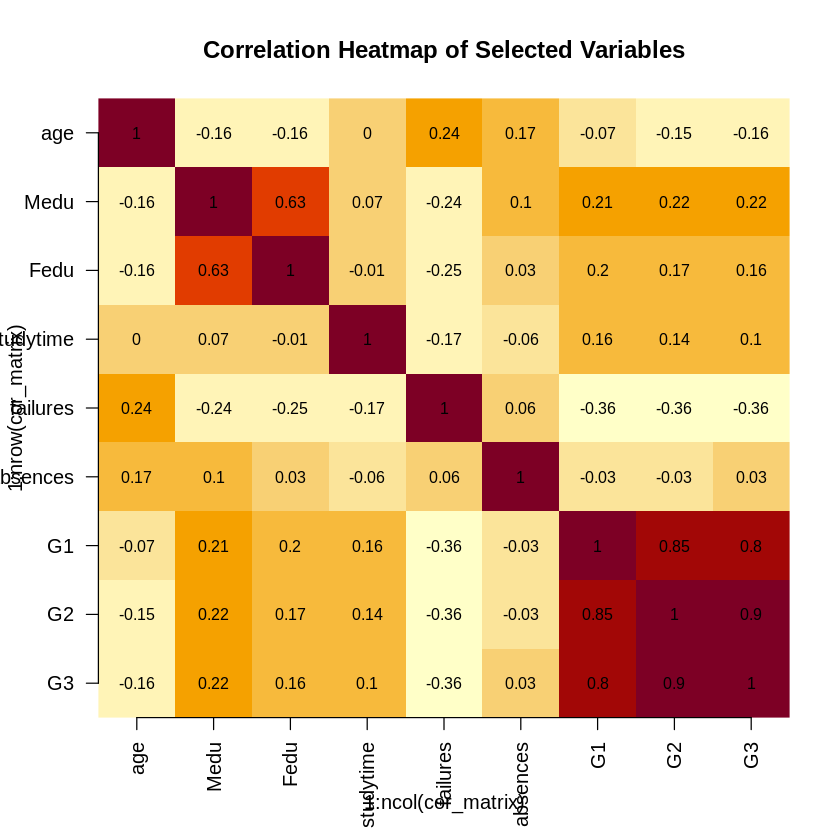

In [52]:
# Select selected numerical variables
selected_data <- student_data[, c("age", "Medu", "Fedu", "studytime",
                                  "failures", "absences", "G1", "G2", "G3")]

# Calculate correlation matrix
cor_matrix <- cor(selected_data, use = "complete.obs")

# Create heatmap
image(1:ncol(cor_matrix),
      1:nrow(cor_matrix),
      t(cor_matrix[nrow(cor_matrix):1, ]),
      axes = FALSE,
      main = "Correlation Heatmap of Selected Variables")

# Add labels
axis(1, at = 1:ncol(cor_matrix), labels = colnames(cor_matrix), las = 2)
axis(2, at = 1:nrow(cor_matrix), labels = rev(colnames(cor_matrix)), las = 2)

# Add correlation values inside squares
for(i in 1:nrow(cor_matrix)){
  for(j in 1:ncol(cor_matrix)){
    text(j,
         nrow(cor_matrix)-i+1,
         round(cor_matrix[i,j], 2),
         cex = 0.8)
  }
}

In [53]:
# Correlation Analysis Findings:
# The correlation heatmap shows the relationships between selected numerical variables and the final grade (G3).

# - Failures shows a negative correlation with G3 (-0.36), suggesting that students with more previous failures tend to have lower final grades.

# - Studytime has a weak positive correlation with G3 (0.10), indicating that study time alone has a limited linear relationship with final performance.

# - Absences has a very weak correlation with G3 (0.03), meaning that the direct linear relationship between absences and final grade is limited in this dataset.

# - Mother's education (Medu) and father's education (Fedu) show moderate positive relationships with each other (0.63), while their correlations with G3 are relatively weak (0.22 and 0.16).

Feature Engineering

In [56]:

# Select important features for prediction model

model_data <- student_data[, c("G1",
                               "G2",
                               "failures",
                               "absences",
                               "studytime",
                               "Medu",
                               "Fedu",
                               "G3")]
model_data

,G1,G2,failures,absences,studytime,Medu,Fedu,G3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5,6,0,4,2,4,4,6
2,5,5,0,4,2,1,1,6
3,7,8,3,10,2,1,1,10
4,15,14,0,2,3,4,2,15
5,6,10,0,4,2,3,3,10
6,15,15,0,10,2,4,3,15
7,12,12,0,0,2,2,2,11
9,16,18,0,0,2,3,2,19
10,14,15,0,0,2,3,4,15


In [55]:
head(model_data)

,G1,G2,failures,absences,studytime,Medu,Fedu,G3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5,6,0,4,2,4,4,6
2,5,5,0,4,2,1,1,6
3,7,8,3,10,2,1,1,10
4,15,14,0,2,3,4,2,15
5,6,10,0,4,2,3,3,10
6,15,15,0,10,2,4,3,15
